In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('train.csv')
data = data[data['label'] == 1]
data = data.drop('label', axis=1)
data = data.dropna()

In [5]:
data = data.groupby('user_id')['text'].apply(lambda x: ' '.join(x)).reset_index()
user_profile = data.copy()
user_profile.head()

,user_id,text
0,U10003,news newsworld trump doubl syria withdraw crit...
1,U10014,lifestyl lifestylebuzz thi percentag american ...
2,U1003,sport icehockey_nhl pro russian hockey team tw...
3,U10030,sport football_ncaa new mexico de nahj flower ...
4,U10044,lifestyl lifestylebuzz thi woman 's wed her dr...


In [6]:
test = pd.read_csv('test.csv')
test = test.dropna()

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
corpus = user_profile['text'].tolist() + test['text'].tolist()
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(corpus)

user_profile_vector = X[:len(user_profile)]
test_vector = X[len(user_profile):]




In [8]:

user_id_to_index = {uid: idx for idx, uid in enumerate(user_profile['user_id'])}




In [9]:
similarities = []
test = test.reset_index(drop=True)


for i, row in test.iterrows():
    user_id = row['user_id']
    user_idx = user_id_to_index.get(user_id)

    if user_idx is not None:
        sim = cosine_similarity(test_vector[i], user_profile_vector[user_idx])[0][0]
    else:
        sim = 0 

    similarities.append(sim)



In [12]:
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve, classification_report

test['similarity'] = similarities
auc = roc_auc_score(test['label'], test['similarity'])
acc = accuracy_score(test['label'], (test['similarity'] > 0.2).astype(int))

print(f"📊 AUC Score: {auc:.4f}")
print(f"✅ Accuracy (threshold=0.2): {acc:.4f}")
print(classification_report(test['label'], (test['similarity'] > 0.2).astype(int)))


📊 AUC Score: 0.5108
✅ Accuracy (threshold=0.2): 0.5430
              precision    recall  f1-score   support

           0       0.54      1.00      0.70    347837
           1       0.99      0.01      0.02    298958

    accuracy                           0.54    646795
   macro avg       0.76      0.51      0.36    646795
weighted avg       0.75      0.54      0.39    646795



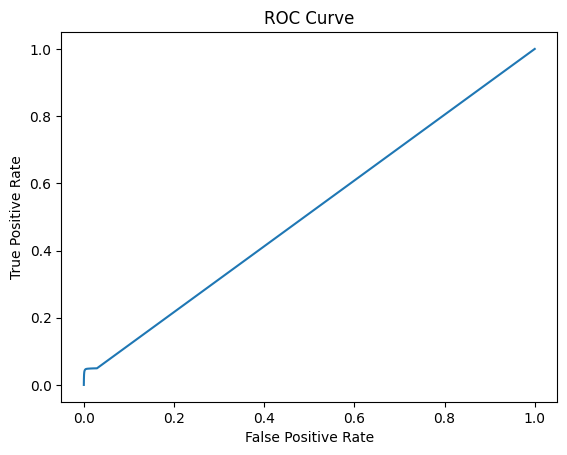

In [13]:
test1 = test.copy()
fpr, tpr, thresholds = roc_curve(test['label'], test['similarity'])
plt.plot(fpr, tpr)
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()
